In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df_cdmx1 = pd.read_csv('./data/CDMX_2015_2020.csv')
df_cdmx2 = pd.read_csv('./data/CDMX_2020_2025.csv')

df_cuerna1 = pd.read_csv('./data/CUERNA_2015_2020.csv')
df_cuerna2 = pd.read_csv('./data/CUERNA_2020_2025.csv')

df_puebla1 = pd.read_csv('./data/PUEBLA_2015_2020.csv')
df_puebla2 = pd.read_csv('./data/PUEBLA_2020_2025.csv')

In [3]:
df_cdmx1 = df_cdmx1[df_cdmx1['DATE'] < '2020-01-01']
df_cuerna1 = df_cuerna1[df_cuerna1['DATE'] < '2020-01-01']
df_puebla1 = df_puebla1[df_puebla1['DATE'] < '2020-01-01']

In [4]:
df_general = pd.concat([df_cdmx1, df_cdmx2,
                        df_cuerna1, df_cuerna2,
                        df_puebla1, df_puebla2]).sort_values(by = 'DATE')

In [5]:
df_general = df_general.reset_index(drop = True)

In [6]:
df_general.drop(['TMAX_ATTRIBUTES', 'TMIN_ATTRIBUTES'], axis = 1, inplace = True)

In [7]:
df_general['TMAX'] = (df_general['TMAX'] - 32)/1.8
df_general['TMIN'] = (df_general['TMIN'] - 32)/1.8

In [8]:
df_general['YEAR'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[0])
df_general['MONTH'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[1])
df_general['DAY'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[2])

In [9]:
df_general.dropna(axis = 0, inplace = True)

In [10]:
df_general

,STATION,NAME,DATE,TMAX,TMIN,YEAR,MONTH,DAY
1,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-01,23.888889,4.444444,2015,01,01
3,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-02,22.222222,4.444444,2015,01,02
4,MXM00076680,"MEXICO CITY, MX",2015-01-02,22.222222,8.333333,2015,01,02
5,MXM00076726,"CUERNAVACA, MX",2015-01-02,27.222222,12.777778,2015,01,02
8,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-03,22.222222,4.444444,2015,01,03
...,...,...,...,...,...,...,...,...
14855,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-27,22.222222,10.555556,2025,11,27
14856,MXM00076680,"MEXICO CITY, MX",2025-11-28,17.777778,11.111111,2025,11,28
14857,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-28,21.111111,8.888889,2025,11,28
14858,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-29,21.111111,6.666667,2025,11,29


In [11]:
df_general_tmin = df_general.drop(['TMAX'], axis = 1)
df_general_tmax = df_general.drop(['TMIN'], axis = 1)

In [12]:
df_tmax = df_general_tmax.groupby(['YEAR', 'MONTH', 'DAY'])
df_tmin = df_general_tmin.groupby(['YEAR', 'MONTH', 'DAY'])

In [13]:
def per_year():
    years = [str(y) for y in range(2015, 2026, 1)]
    year = input("Enter a year from 2015 to 2025 (leave blank for all years): ").strip()

    if year and year not in years:
        print("Invalid year")
        return

    if year:
        fig, ax = plt.subplots(figsize = (16, 6))
        axes = [ax]
        years_to_plot = [year]
        filename = 'temperaturas_' + year + '.png'
    else:
        fig, ax = plt.subplots(len(years), 1, figsize = (16, 40))
        axes = ax
        years_to_plot = years
        filename = 'temperaturas_2015_a_2025.png'

    for i in range(len(years_to_plot)):
        current_year = years_to_plot[i]
        tmax = np.array(df_tmax.max().loc[current_year]['TMAX'])
        tmin = np.array(df_tmin.min().loc[current_year]['TMIN'])
        locs = np.linspace(0, len(tmax) - 1, 12)

        axes[i].plot(tmin, label = '$T_{min}$')
        axes[i].plot(tmax, label = '$T_{max}$')
        axes[i].grid(alpha = 0.3)
        axes[i].legend()
        axes[i].set_title(current_year)
        axes[i].set_xticks(locs)
        axes[i].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[i].set_ylabel('T [°C]')

    plt.tight_layout()
    plt.savefig(filename, dpi = 300, bbox_inches = 'tight')
    plt.show()

In [14]:
def yearly_avg():
    years = [str(y) for y in range(2015, 2026, 1)]
    tmax_avg = []
    tmin_avg = []

    for i in range(len(years)):
        year = years[i]
        tmax = np.array(df_tmax.max().loc[year]['TMAX'])
        tmin = np.array(df_tmin.min().loc[year]['TMIN'])
        tmax_avg.append(tmax.mean())
        tmin_avg.append(tmin.mean())

    flag = input("Choose: \n"
                 "[1] for bar graph \n"
                 "[2] for line graph \n")

    plt.figure(figsize = (12, 6))
    if flag == '1':
        x = np.arange(len(years))
        width = 0.4
        plt.bar(x - width/2, tmax_avg, width, label = '$T_{max}$')
        plt.bar(x + width/2, tmin_avg, width, label = '$T_{min}$')
        plt.xticks(x, years)
    elif flag == '2':
        plt.plot(years, tmax_avg, marker = 'o', label = '$T_{max}$')
        plt.plot(years, tmin_avg, marker = 'o', label = '$T_{min}$')
        plt.xticks(years)
    else:
        plt.close()
        print("Invalid choice")
        return

    plt.ylabel('T [°C]')
    plt.grid(alpha = 0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('temperaturas_promedio_2015_a_2025.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

In [15]:
def records():
    dates = []
    maximum = []
    minimum = []
    max_breaks = []
    min_breaks = []

    for month in range(1, 13):
        for day in range(1, 32):
            data = df_general[
                (df_general['MONTH'] == str(month).zfill(2))
                & (df_general['DAY'] == str(day).zfill(2))
            ]
            old = data[
                (data['YEAR'] >= '2015')
                & (data['YEAR'] <= '2024')
            ]
            new = data[data['YEAR'] == '2025']

            if len(old):
                dates.append(str(month) + '-' + str(day))
                maximum.append(old['TMAX'].max())
                minimum.append(old['TMIN'].min())

                if len(new) and new['TMAX'].max() > maximum[-1]:
                    max_breaks.append(new['TMAX'].max())
                else:
                    max_breaks.append(np.nan)

                if len(new) and new['TMIN'].min() < minimum[-1]:
                    min_breaks.append(new['TMIN'].min())
                else:
                    min_breaks.append(np.nan)

    x = range(len(dates))
    labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_positions = []
    month_labels = []

    for month in range(1, 13):
        for i in range(len(dates)):
            if dates[i].split('-')[0] == str(month):
                month_positions.append(i)
                month_labels.append(labels[month - 1])
                break

    plt.figure(figsize = (18, 6))
    plt.plot(x, minimum, alpha = 0.5, label = '$T_{min}$ record 2015-2024')
    plt.plot(x, maximum, alpha = 0.5, label = '$T_{max}$ record 2015-2024')
    plt.scatter(x, max_breaks, color = 'black', marker = 'o', label = '2025 max record')
    plt.scatter(x, min_breaks, color = 'black', marker = 'v', label = '2025 min record')
    plt.xticks(month_positions, month_labels)
    plt.ylabel('T [°C]')
    plt.grid(alpha = 0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('climatologia_record_2015_a_2025.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

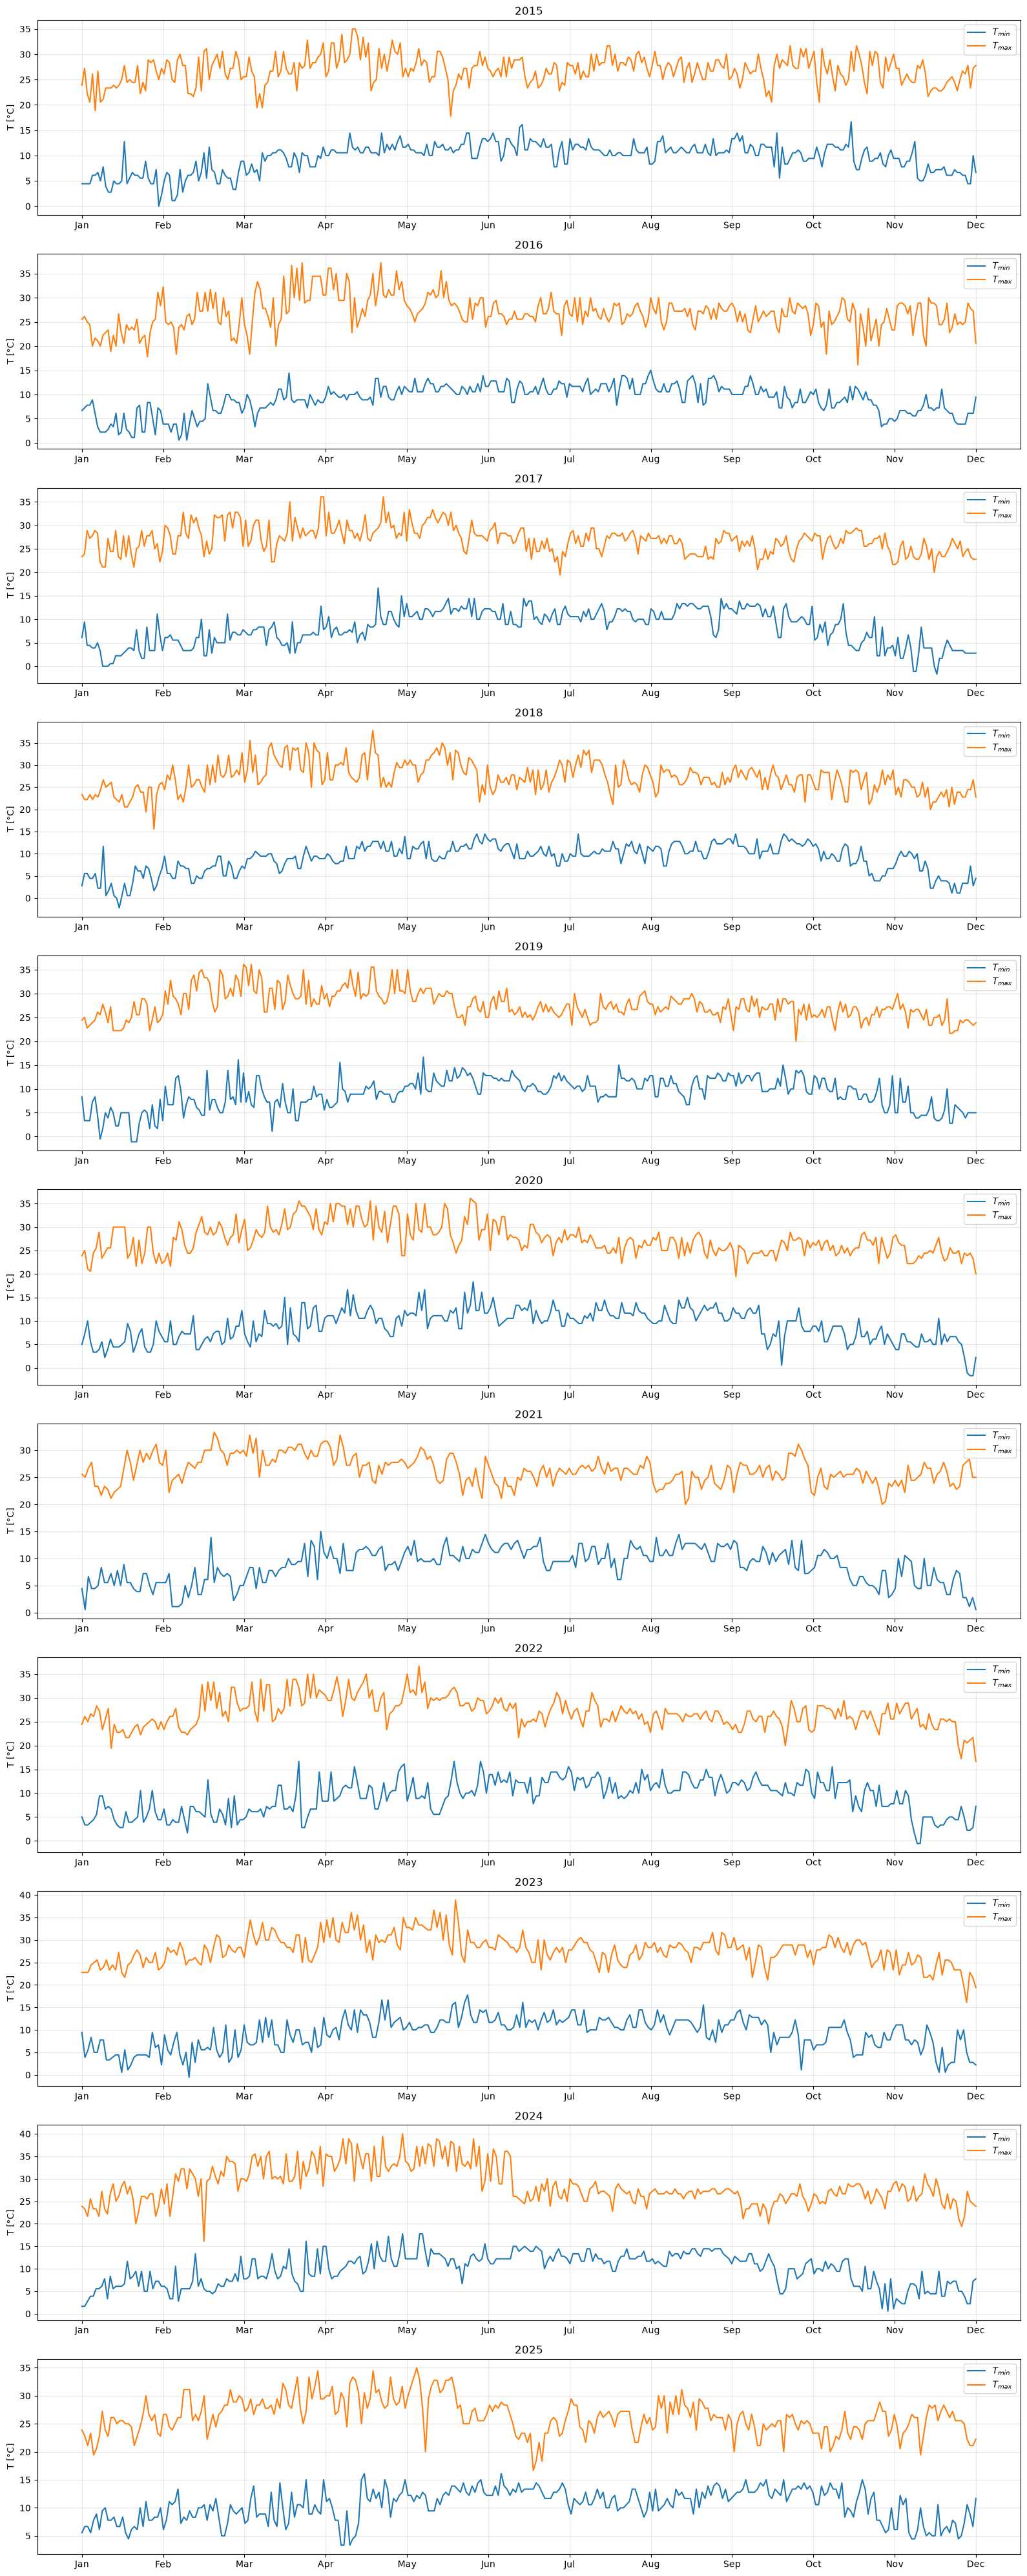

In [16]:
per_year()

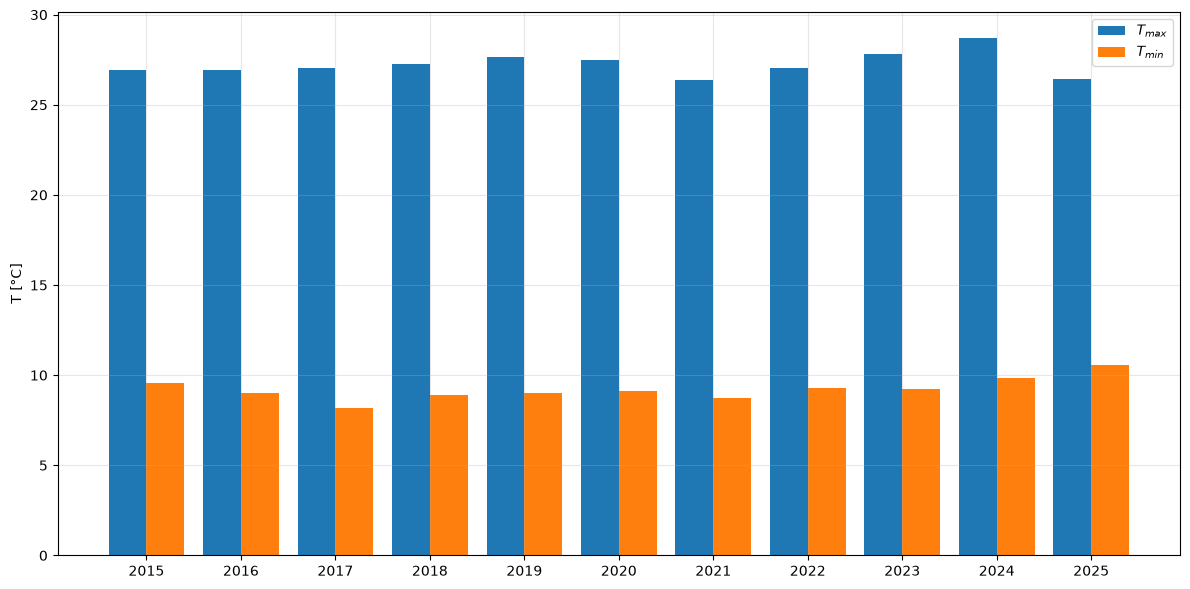

In [17]:
yearly_avg()

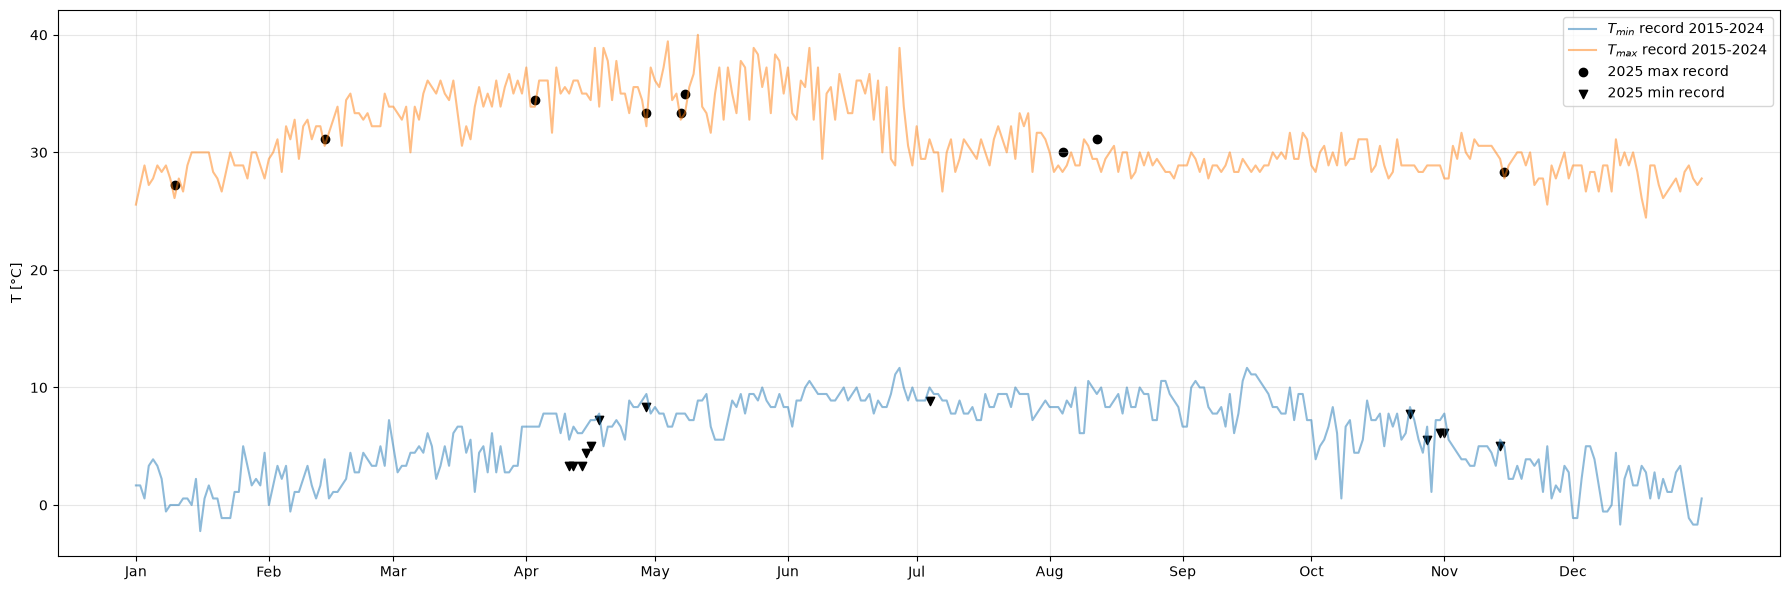

In [18]:
records()